# Specific Stock Simulation


In [1]:
import matplotlib.pyplot as plt
import analysis_interfaces.interface_specific_stock as iss


## Block 1: Parameters


In [2]:
ticker = "PDD"
initial_funds = 100
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

period = "1y"  # Valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max

## Block 4: Simulate Daily Buy/Sell/Hold Strategy


In [3]:
df_pred = iss.build_prediction_and_stats(
            ticker,
            include_sentiment=include_sentiment,
            period=period,
        )

In [4]:
simulation_result = iss.simulate_prediction_signal_strategy(
    df_pred,
    initial_funds=initial_funds,
)


## Block 5: Portfolio Summary


In [5]:
df_pred

,Date,Open,High,Low,Close,Adj Close,Volume,TICKER,SMA10,SMA20,...,VWAP,Daily_Return,Cumulative_Return,Daily Gain/Loss,technical_analysis_buy_score,technical_analysis_sell_score,fundamental_analysis_score,sentiment_analysis_score,Signal,Signal_Text
0,2026-03-16,104.614998,105.540001,103.459999,104.620003,104.620003,1760685,PDD,NaN,NaN,...,104.620003,NaN,NaN,0.005005,0.00,-0.10,0.8875,0,0.039625,HOLD
1,2026-03-13,102.529999,103.629997,102.129997,102.650002,102.650002,4738500,PDD,NaN,NaN,...,103.183692,-0.018830,-0.018830,0.120003,0.10,-0.45,0.8875,0,-0.416000,WEAK SELL
2,2026-03-12,102.529999,103.889999,101.389999,101.620003,101.620003,6350800,PDD,NaN,NaN,...,102.410876,-0.010034,-0.028675,-0.909996,0.10,-0.45,0.8875,0,-0.416000,WEAK SELL
3,2026-03-11,104.629997,104.750000,102.480003,102.940002,102.940002,4475300,PDD,NaN,NaN,...,102.547555,0.012990,-0.016058,-1.689995,0.00,-0.55,0.8875,0,-0.780500,WEAK SELL
4,2026-03-10,103.529999,106.570000,103.419998,104.860001,104.860001,7767100,PDD,NaN,NaN,...,103.263349,0.018652,0.002294,1.330002,0.00,-0.55,0.8875,0,-0.780500,WEAK SELL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2025-03-21,127.470001,127.830002,123.269997,126.639999,126.639999,13463600,PDD,122.056999,108.333000,...,113.303484,-0.011552,0.210476,-0.830002,0.65,-0.40,0.8875,0,0.677500,WEAK BUY
247,2025-03-20,122.620003,131.520004,119.099998,130.919998,130.919998,33353900,PDD,123.781999,110.194500,...,113.578465,0.033797,0.251386,8.299995,0.65,-0.40,0.8875,0,0.677500,WEAK BUY
248,2025-03-19,129.220001,129.360001,123.160004,125.919998,125.919998,13343500,PDD,124.466999,111.873000,...,113.655055,-0.038191,0.203594,-3.300003,0.65,-0.40,0.8875,0,0.677500,WEAK BUY
249,2025-03-18,128.000000,128.919998,125.879997,126.790001,126.790001,8165800,PDD,124.926999,113.509000,...,113.704750,0.006909,0.211910,-1.209999,0.60,-0.45,0.8875,0,0.495250,WEAK BUY


In [6]:
simulation_result["price_history"]

,Date,Open,Close,Trade_Price
0,2025-03-17,123.000000,128.899994,125.949997
1,2025-03-18,128.000000,126.790001,127.395000
2,2025-03-19,129.220001,125.919998,127.570000
3,2025-03-20,122.620003,130.919998,126.770000
4,2025-03-21,127.470001,126.639999,127.055000
...,...,...,...,...
246,2026-03-10,103.529999,104.860001,104.195000
247,2026-03-11,104.629997,102.940002,103.785000
248,2026-03-12,102.529999,101.620003,102.075001
249,2026-03-13,102.529999,102.650002,102.590000


In [7]:
simulation_result["daily_history"]

,Date,Open,Close,Trade_Price,signal_text,signal_number,action,trade_units,trade_value,cash_balance,units_held,average_cost_per_unit,holdings_value,portfolio_value,profit_loss,profit_loss_pct
0,2025-03-17,123.000000,128.899994,125.949997,WEAK BUY,1,BUY,0.039698,5.000000,95.000000,0.039698,125.949997,5.117110,100.117110,0.117110,0.117110
1,2025-03-18,128.000000,126.790001,127.395000,WEAK BUY,1,BUY,0.039248,5.000000,90.000000,0.078946,126.668378,10.009602,100.009602,0.009602,0.009602
2,2025-03-19,129.220001,125.919998,127.570000,WEAK BUY,1,BUY,0.039194,5.000000,85.000000,0.118140,126.967499,14.876248,99.876248,-0.123752,-0.123752
3,2025-03-20,122.620003,130.919998,126.770000,WEAK BUY,1,BUY,0.039442,5.000000,80.000000,0.157582,126.918067,20.630632,100.630632,0.630632,0.630632
4,2025-03-21,127.470001,126.639999,127.055000,WEAK BUY,1,BUY,0.039353,5.000000,75.000000,0.196935,126.945430,24.939850,99.939850,-0.060150,-0.060150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
246,2026-03-10,103.529999,104.860001,104.195000,WEAK SELL,-1,SELL,0.024230,2.524630,28.869401,0.460367,116.639598,48.274114,77.143516,-22.856484,-22.856484
247,2026-03-11,104.629997,102.940002,103.785000,WEAK SELL,-1,SELL,0.023018,2.388961,31.258362,0.437349,116.639598,45.020700,76.279062,-23.720938,-23.720938
248,2026-03-12,102.529999,101.620003,102.075001,WEAK SELL,-1,SELL,0.021867,2.232120,33.490482,0.415481,116.639598,42.221229,75.711711,-24.288289,-24.288289
249,2026-03-13,102.529999,102.650002,102.590000,WEAK SELL,-1,SELL,0.020774,2.131212,35.621694,0.394707,116.639598,40.516716,76.138410,-23.861590,-23.861590


In [8]:
simulation_result["transactions"]


,Date,action,signal_text,trade_price,units,trade_value,cash_balance,units_held,portfolio_value
0,2025-03-17,BUY,WEAK BUY,125.949997,0.039698,5.000000,95.000000,0.039698,100.117110
1,2025-03-18,BUY,WEAK BUY,127.395000,0.039248,5.000000,90.000000,0.078946,100.009602
2,2025-03-19,BUY,WEAK BUY,127.570000,0.039194,5.000000,85.000000,0.118140,99.876248
3,2025-03-20,BUY,WEAK BUY,126.770000,0.039442,5.000000,80.000000,0.157582,100.630632
4,2025-03-21,BUY,WEAK BUY,127.055000,0.039353,5.000000,75.000000,0.196935,99.939850
...,...,...,...,...,...,...,...,...,...
119,2026-03-09,SELL,WEAK SELL,101.825001,0.025505,2.597058,26.344771,0.484597,76.083822
120,2026-03-10,SELL,WEAK SELL,104.195000,0.024230,2.524630,28.869401,0.460367,77.143516
121,2026-03-11,SELL,WEAK SELL,103.785000,0.023018,2.388961,31.258362,0.437349,76.279062
122,2026-03-12,SELL,WEAK SELL,102.075001,0.021867,2.232120,33.490482,0.415481,75.711711


In [9]:
simulation_result["summary"]


,start_date,end_date,initial_funds,ending_cash_balance,units_held,average_cost_per_unit,latest_close,holdings_value,total_portfolio_value,profit_loss,profit_loss_pct,buy_transactions,sell_transactions
0,2025-03-17,2026-03-16,100.0,35.621694,0.394707,116.639598,104.620003,41.29429,76.915984,-23.084016,-23.084016,43,81


## Block 6: Consolidated Chart


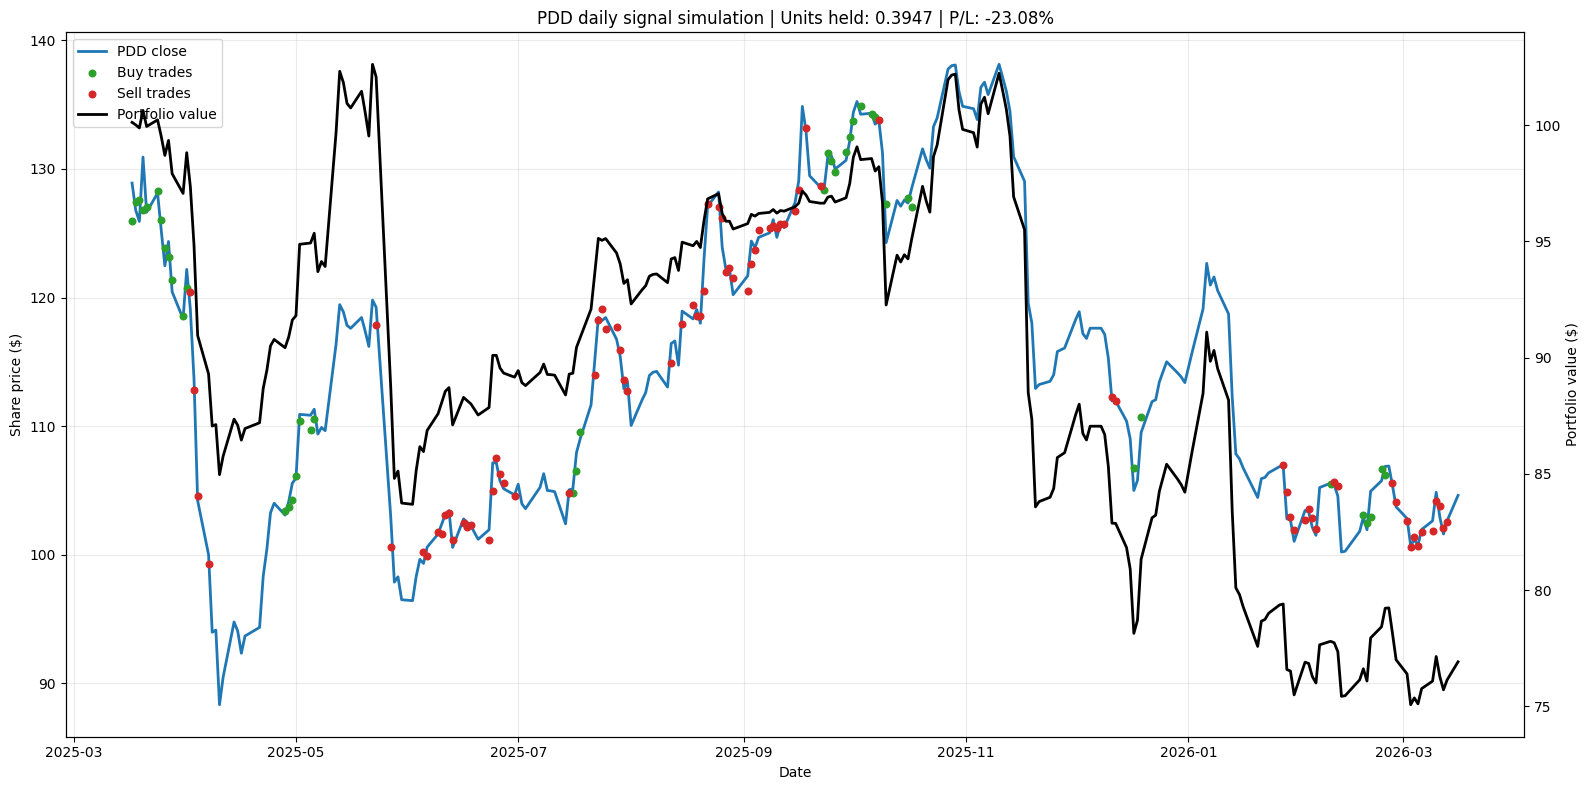

In [10]:
price_history = simulation_result["price_history"].copy()
daily_history = simulation_result["daily_history"].copy()
transactions = simulation_result["transactions"].copy()
simulation_summary = simulation_result["summary"].iloc[0]

buy_txns = transactions[transactions["action"] == "BUY"].copy()
sell_txns = transactions[transactions["action"] == "SELL"].copy()

fig, ax_price = plt.subplots(figsize=(16, 8))
ax_price.plot(
    price_history["Date"],
    price_history["Close"],
    color="#1f77b4",
    linewidth=2,
    label=f"{ticker} close",
)

if not buy_txns.empty:
    ax_price.scatter(
        buy_txns["Date"],
        buy_txns["trade_price"],
        color="#2ca02c",
        marker=".",
        s=90,
        label="Buy trades",
        zorder=5,
    )

if not sell_txns.empty:
    ax_price.scatter(
        sell_txns["Date"],
        sell_txns["trade_price"],
        color="#d62728",
        marker=".",
        s=90,
        label="Sell trades",
        zorder=5,
    )

ax_price.set_xlabel("Date")
ax_price.set_ylabel("Share price ($)")
ax_price.grid(alpha=0.25)

ax_portfolio = ax_price.twinx()
ax_portfolio.plot(
    daily_history["Date"],
    daily_history["portfolio_value"],
    color="#000000",
    linewidth=2,
    label="Portfolio value",
)
ax_portfolio.set_ylabel("Portfolio value ($)")

title = (
    f"{ticker} daily signal simulation | "
    f"Units held: {simulation_summary['units_held']:.4f} | "
    f"P/L: {simulation_summary['profit_loss_pct']:.2f}%"
)
ax_price.set_title(title)

handles_price, labels_price = ax_price.get_legend_handles_labels()
handles_portfolio, labels_portfolio = ax_portfolio.get_legend_handles_labels()
ax_price.legend(handles_price + handles_portfolio, labels_price + labels_portfolio, loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Block 7: Daily Portfolio History


In [11]:
simulation_result["daily_history"][[
    "Date",
    "signal_text",
    "action",
    "trade_units",
    "trade_value",
    "cash_balance",
    "units_held",
    "holdings_value",
    "portfolio_value",
    "profit_loss_pct",
]]


,Date,signal_text,action,trade_units,trade_value,cash_balance,units_held,holdings_value,portfolio_value,profit_loss_pct
0,2025-03-17,WEAK BUY,BUY,0.039698,5.000000,95.000000,0.039698,5.117110,100.117110,0.117110
1,2025-03-18,WEAK BUY,BUY,0.039248,5.000000,90.000000,0.078946,10.009602,100.009602,0.009602
2,2025-03-19,WEAK BUY,BUY,0.039194,5.000000,85.000000,0.118140,14.876248,99.876248,-0.123752
3,2025-03-20,WEAK BUY,BUY,0.039442,5.000000,80.000000,0.157582,20.630632,100.630632,0.630632
4,2025-03-21,WEAK BUY,BUY,0.039353,5.000000,75.000000,0.196935,24.939850,99.939850,-0.060150
...,...,...,...,...,...,...,...,...,...,...
246,2026-03-10,WEAK SELL,SELL,0.024230,2.524630,28.869401,0.460367,48.274114,77.143516,-22.856484
247,2026-03-11,WEAK SELL,SELL,0.023018,2.388961,31.258362,0.437349,45.020700,76.279062,-23.720938
248,2026-03-12,WEAK SELL,SELL,0.021867,2.232120,33.490482,0.415481,42.221229,75.711711,-24.288289
249,2026-03-13,WEAK SELL,SELL,0.020774,2.131212,35.621694,0.394707,40.516716,76.138410,-23.861590
